# Fase 1: Carregamento, Limpeza de Dados e EDA (Análise Exploratória)
**Projeto:** Sistema NDR com ML em Duas Camadas (TCC)
**Dataset:** CICIDS 2017

## Objetivos deste Notebook:
1. Montar o Google Drive e carregar os 8 arquivos CSV do CICIDS 2017.
2. Concatenar todos os dados em um único DataFrame.
3. Realizar a limpeza profunda (tratamento de NaNs, Infinitos, Duplicatas, etc.).
4. Tratar classes muito raras e preparar os targets para as duas camadas (Binária e Multiclasse).
5. Conduzir a Análise Exploratória de Dados (EDA).


In [1]:
# Importando as bibliotecas essenciais para esta fase
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import gc # Garbage Collector para ajudar a liberar memória RAM

# Configurações visuais para os gráficos
plt.style.use('ggplot')
sns.set_palette("husl")
pd.set_option('display.max_columns', 100) # Mostrar todas as colunas
pd.set_option('display.float_format', lambda x: '%.5f' % x) # Evitar notação científica chata

# Conectando com o Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Defina o caminho onde os CSVs estão no seu Drive.
# Ajuste este caminho se sua pasta tiver outro nome.
DATA_PATH = '/content/drive/MyDrive/TCC2/MachineLearningCVE/'

print("\nArquivos disponíveis no diretório:")
try:
    print(os.listdir(DATA_PATH))
except FileNotFoundError:
    print(f"ATENÇÃO: A pasta '{DATA_PATH}' não foi encontrada. Verifique o caminho.")


Mounted at /content/drive

Arquivos disponíveis no diretório:
['Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv', 'Wednesday-workingHours.pcap_ISCX.csv', 'Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv', 'Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv', 'Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv', 'Tuesday-WorkingHours.pcap_ISCX.csv', 'Monday-WorkingHours.pcap_ISCX.csv', 'Friday-WorkingHours-Morning.pcap_ISCX.csv']


### 1.1 Carregamento e Concatenação dos Dados
Nesta etapa, leremos todos os 8 arquivos CSV do diretório e os uniremos. Também aplicaremos a remoção de espaços em branco (strip) nos nomes das colunas para padronização.


In [3]:
# Lista para guardar os DataFrames temporariamente
df_list = []

# Listar os arquivos do diretório
arquivos = [f for f in os.listdir(DATA_PATH) if f.endswith('.csv')]

print("Iniciando a leitura dos arquivos...")

for arquivo in arquivos:
    print(f"Lendo {arquivo}...")
    file_path = os.path.join(DATA_PATH, arquivo)

    # Lendo o CSV. O CICIDS 2017 usa utf-8, mas caso haja problema, cp1252 é o fallback comum.
    temp_df = pd.read_csv(file_path)
    df_list.append(temp_df)

# Concatenando todos os arquivos
print("\nConcatenando todos os DataFrames...")
df = pd.concat(df_list, ignore_index=True)

# Limpando a lista temporária da memória (boa prática no Colab)
del df_list
gc.collect()

# Limpando os nomes das colunas (removendo espaços no início e no fim)
df.columns = df.columns.str.strip()

print(f"\nDataset final carregado com sucesso!")
print(f"Total de linhas: {df.shape[0]}")
print(f"Total de colunas (features): {df.shape[1]}")


Iniciando a leitura dos arquivos...
Lendo Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv...
Lendo Wednesday-workingHours.pcap_ISCX.csv...
Lendo Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv...
Lendo Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv...
Lendo Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv...
Lendo Tuesday-WorkingHours.pcap_ISCX.csv...
Lendo Monday-WorkingHours.pcap_ISCX.csv...
Lendo Friday-WorkingHours-Morning.pcap_ISCX.csv...

Concatenando todos os DataFrames...

Dataset final carregado com sucesso!
Total de linhas: 2830743
Total de colunas (features): 79


### 1.2 Limpeza de Dados
O dataset bruto possui algumas anomalias que prejudicam os modelos de ML. Nesta etapa vamos:
1. Substituir valores infinitos (comuns em divisões por zero de pacotes/bytes) por NaNs.
2. Identificar e remover linhas com valores nulos (NaN).
3. Remover linhas completamente duplicadas (pacotes registrados duplamente).
4. Corrigir colunas com strings ocultas e forçar os tipos numéricos (`float64`).
5. Remover a coluna `'Fwd Header Length'` que, por erro da extração original, aparece duplicada.


In [4]:
print("Tamanho original:", df.shape)

# 1. Substituir valores Infinitos por NaN
# Quando calculamos Bytes/s, se o tempo for zero, a divisão dá infinito.
df.replace([np.inf, -np.inf], np.nan, inplace=True)
print("\nValores Infinitos substituídos por NaN.")

# 2. Lidando com valores Faltantes (NaN)
nan_count = df.isna().sum().sum()
print(f"Total de valores nulos (NaN) encontrados: {nan_count}")

# Como o dataset é gigantesco, dropar linhas com NaN não nos afetará.
df.dropna(inplace=True)
print("Linhas com NaN removidas.")

# 3. Tratando valores duplicados
duplicadas = df.duplicated().sum()
print(f"Linhas duplicadas exatas encontradas: {duplicadas}")
df.drop_duplicates(inplace=True)
print("Linhas duplicadas removidas.")

# 4. Limpeza da feature duplicada
# O CICIDS 2017 exporta duas colunas com o mesmo nome: 'Fwd Header Length'.
# Vamos deletar a que estiver duplicada.
df = df.loc[:, ~df.columns.duplicated()]
print("\nColuna 'Fwd Header Length' duplicada foi removida.")

# 5. Tratamento de tipos de dados (Cast para numérico)
# Existem colunas numéricas que as vezes são carregadas como 'object' (string) por sujeira.
# Ex: 'Flow Bytes/s' e 'Flow Packets/s'.
# Vamos garantir que TUDO seja float64, exceto a nossa coluna alvo (Label).

cols_to_convert = df.columns.difference(['Label'])
for col in cols_to_convert:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Como o to_numeric com 'coerce' pode ter gerado novos NaNs onde havia texto corrompido, dropamos novamente:
df.dropna(inplace=True)

print(f"\nTamanho limpo: {df.shape}")


Tamanho original: (2830743, 79)

Valores Infinitos substituídos por NaN.
Total de valores nulos (NaN) encontrados: 5734
Linhas com NaN removidas.
Linhas duplicadas exatas encontradas: 307078
Linhas duplicadas removidas.

Coluna 'Fwd Header Length' duplicada foi removida.

Tamanho limpo: (2520798, 79)


### Remoção de Colunas Constantes (Variância Zero)
Colunas que possuem o mesmo valor para todas as linhas não agregam nenhuma informação para a Rede Neural ou para as Árvores de Decisão. Pior, elas gastam memória e processamento à toa. Vamos identificar e deletar essas colunas.


In [5]:
# Identificando colunas numéricas cujo desvio padrão é zero (ou muito próximo)
# Dica: std == 0 significa que não há variação nos dados (são constantes)
colunas_constantes = [col for col in cols_to_convert if df[col].std() == 0]

print(f"Foram encontradas {len(colunas_constantes)} colunas constantes. São elas:")
print(colunas_constantes)

# Removendo essas colunas
df.drop(columns=colunas_constantes, inplace=True)

print(f"\nColunas constantes removidas. Novo tamanho do dataset: {df.shape}")


Foram encontradas 8 colunas constantes. São elas:
['Bwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd PSH Flags', 'Bwd URG Flags', 'Fwd Avg Bulk Rate', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk']

Colunas constantes removidas. Novo tamanho do dataset: (2520798, 71)


### 1.3 e 1.4 Tratamento de Classes Raras e Engenharia do Target
Nesta etapa vamos:
1. Verificar a distribuição das classes.
2. Remover classes residuais (menos de 50 amostras) para evitar ruídos no treinamento (Infiltration, Heartbleed e SQL Injection).
3. Criar a **Camada 1 (Binária)**: classificar tráfego entre `0` (BENIGN) e `1` (Attack).
4. Criar a **Camada 2 (Multiclasse)**: Separar apenas os ataques em um DataFrame paralelo e transformar as labels em números (`Label Encoding`).


In [ ]:
print("Distribuição original dos Labels:")
print(df['Label'].value_counts())

# O nome exato das labels pode ter caracteres esquisitos dependendo do encoding (ex: "Web Attack  Sql Injection").
# Para garantir, vamos agrupar os ataques que possuem menos de 50 amostras e removê-los.
contagem_labels = df['Label'].value_counts()
labels_raras = contagem_labels[contagem_labels < 50].index.tolist()

print(f"\nLabels com menos de 50 amostras (serão removidas): {labels_raras}")

# Removendo do DataFrame
df = df[~df['Label'].isin(labels_raras)]

print(f"\nDistribuição após remoção das classes raras:")
print(df['Label'].value_counts())


In [6]:
from sklearn.preprocessing import LabelEncoder

# ---------------------------------------------------------
# PREPARANDO A CAMADA 1: Binária (Normal vs Ataque)
# ---------------------------------------------------------
# Vamos criar uma nova coluna onde 0 é BENIGN e 1 é Ataque
df['is_attack'] = (df['Label'] != 'BENIGN').astype(int)

print("Distribuição da Camada 1 (0 = BENIGN, 1 = ATTACK):")
print(df['is_attack'].value_counts(normalize=True) * 100) # Mostra em porcentagem


# ---------------------------------------------------------
# PREPARANDO A CAMADA 2: Multiclasse (Somente Ataques)
# ---------------------------------------------------------
# Filtramos nosso DataFrame para manter apenas as linhas onde is_attack é igual a 1
df_attacks = df[df['is_attack'] == 1].copy()

# A coluna Label ainda está em texto (string). Algoritmos de ML não leem texto.
# Precisamos convertê-las para números usando LabelEncoder (Ex: DoS Hulk -> 0, PortScan -> 1...)
le_attacks = LabelEncoder()
df_attacks['attack_type_encoded'] = le_attacks.fit_transform(df_attacks['Label'])

print(f"\nTamanho do Dataset da Camada 2 (Somente Ataques): {df_attacks.shape}")

# Vamos salvar o mapeamento para sabermos qual número representa qual ataque depois!
mapeamento_ataques = dict(zip(le_attacks.classes_, le_attacks.transform(le_attacks.classes_)))
print("\nMapeamento de Ataques (Label Encoding):")
for nome_ataque, numero in mapeamento_ataques.items():
    print(f"[{numero}] -> {nome_ataque}")


Distribuição da Camada 1 (0 = BENIGN, 1 = ATTACK):
is_attack
0   83.11086
1   16.88914
Name: proportion, dtype: float64

Tamanho do Dataset da Camada 2 (Somente Ataques): (425741, 73)

Mapeamento de Ataques (Label Encoding):
[0] -> Bot
[1] -> DDoS
[2] -> DoS GoldenEye
[3] -> DoS Hulk
[4] -> DoS Slowhttptest
[5] -> DoS slowloris
[6] -> FTP-Patator
[7] -> Heartbleed
[8] -> Infiltration
[9] -> PortScan
[10] -> SSH-Patator
[11] -> Web Attack � Brute Force
[12] -> Web Attack � Sql Injection
[13] -> Web Attack � XSS


In [7]:
# Lista exata das classes problemáticas baseada na sua saída
classes_para_remover = [
    'Heartbleed',
    'Infiltration',
    'Web Attack  Sql Injection'
]

print("Tamanho do DataFrame Camada 2 antes da limpeza forçada:", df_attacks.shape)

# Removendo essas classes do DataFrame da Camada 2 (Ataques)
df_attacks = df_attacks[~df_attacks['Label'].isin(classes_para_remover)]

# E também precisamos garantir que saiam do DataFrame Principal (Camada 1)
# pois não queremos que esses ataques extremamente raros sejam classificados
# nem como BENIGN, nem como ATTACK, queremos descartá-los.
df = df[~df['Label'].isin(classes_para_remover)]

# Atualizando o Label Encoder para esquecer que esses ataques existiram
le_attacks = LabelEncoder()
df_attacks['attack_type_encoded'] = le_attacks.fit_transform(df_attacks['Label'])

print("Tamanho do DataFrame Camada 2 DEPOIS da limpeza forçada:", df_attacks.shape)
print(f"Total de classes multiclasse restando: {len(le_attacks.classes_)}")


Tamanho do DataFrame Camada 2 antes da limpeza forçada: (425741, 73)
Tamanho do DataFrame Camada 2 DEPOIS da limpeza forçada: (425694, 73)
Total de classes multiclasse restando: 12


### 1.5 Análise Exploratória de Dados (EDA)
Com os dados limpos, vamos extrair insights visuais.
Nesta etapa vamos plotar:
1. Um gráfico de barras com a distribuição do tráfego (Benigno vs Ataques).
2. Um gráfico de barras com as contagens exatas de cada tipo de ataque na Camada 2.
3. A Matriz de Correlação das principais features, para entender quais variáveis andam juntas e se há redundância (multicolinearidade).


/tmp/ipykernel_10483/3657072076.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='is_attack', palette=['#1e5f3a', '#5f1e3a'], ax=ax[0])
/tmp/ipykernel_10483/3657072076.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_attacks, y='Label', order=df_attacks['Label'].value_counts().index, palette='rocket', ax=ax[1])


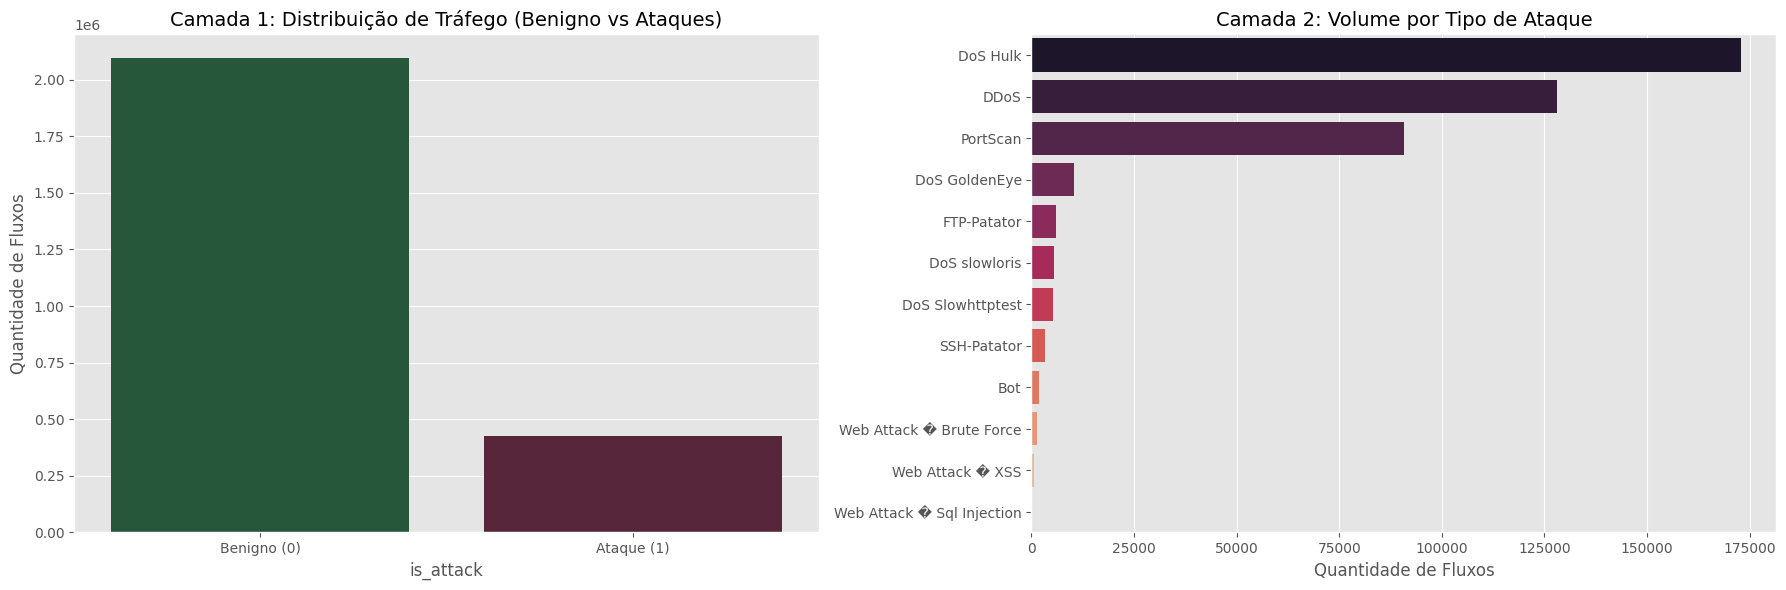

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(18, 6))

# Gráfico 1: Camada 1 (Binária)
sns.countplot(data=df, x='is_attack', palette=['#1e5f3a', '#5f1e3a'], ax=ax[0])
ax[0].set_title('Camada 1: Distribuição de Tráfego (Benigno vs Ataques)', fontsize=14)
ax[0].set_xticks([0, 1])
ax[0].set_xticklabels(['Benigno (0)', 'Ataque (1)'])
ax[0].set_ylabel('Quantidade de Fluxos')

# Gráfico 2: Camada 2 (Tipos de Ataque)
# Vamos plotar na horizontal para facilitar a leitura dos nomes
sns.countplot(data=df_attacks, y='Label', order=df_attacks['Label'].value_counts().index, palette='rocket', ax=ax[1])
ax[1].set_title('Camada 2: Volume por Tipo de Ataque', fontsize=14)
ax[1].set_xlabel('Quantidade de Fluxos')
ax[1].set_ylabel('')

plt.tight_layout()
plt.show()


Como temos mais de 70 features numéricas, plotar todas juntas vira um borrão.

Vamos calcular a correlação de Pearson para a Camada 1, selecionar as 20 features com maior correlação com o target 'is_attack', e plotar apenas entre elas!

Top 20 Features que mais indicam um ataque:
Bwd Packet Length Std    0.61175
Bwd Packet Length Max    0.59651
Bwd Packet Length Mean   0.59444
Avg Bwd Segment Size     0.59444
Packet Length Std        0.57350
Max Packet Length        0.55549
Packet Length Variance   0.53679
Average Packet Size      0.52162
Packet Length Mean       0.52096
Fwd IAT Std              0.50613
Idle Max                 0.47561
Flow IAT Max             0.47152
Idle Mean                0.47087
Fwd IAT Max              0.47080
Idle Min                 0.45845
Flow IAT Std             0.41098
Fwd IAT Total            0.28002
Flow Duration            0.27895
Min Packet Length        0.27694
FIN Flag Count           0.27196
Name: is_attack, dtype: float64


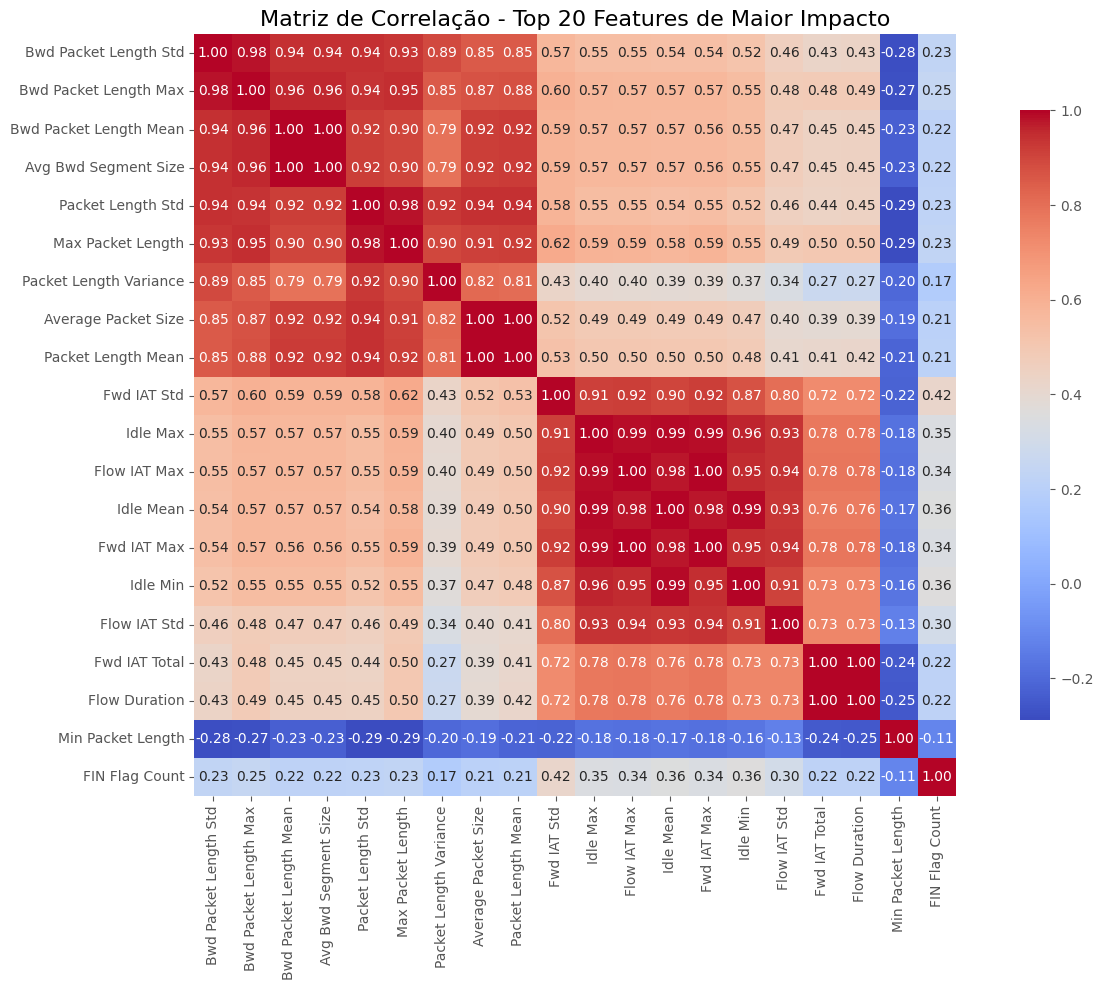

In [9]:
# Calculando a correlação de todas as numéricas com 'is_attack'
correlacoes = df.corr(numeric_only=True)['is_attack'].abs().sort_values(ascending=False)

# Pegando as 20 features mais fortes (descartando a própria is_attack)
top_20_features = correlacoes.index[1:21]

print("Top 20 Features que mais indicam um ataque:")
print(correlacoes[1:21])

# Filtrando o dataframe apenas para essas top 20
df_top20 = df[top_20_features]

# Calculando a matriz de correlação dessas 20 features
corr_matrix = df_top20.corr(numeric_only=True)

# Plotando o Heatmap (Mapa de Calor)
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix,
            annot=True,        # Mostra os números
            fmt=".2f",         # 2 casas decimais
            cmap="coolwarm",   # Azul = Inversamente, Vermelho = Altamente Correlacionado
            square=True,
            cbar_kws={"shrink": .8})

plt.title('Matriz de Correlação - Top 20 Features de Maior Impacto', fontsize=16)
plt.tight_layout()
plt.show()


### Conclusões da EDA e Exportação
O Heatmap revela fortes correlações (quadrados vermelhos escuros) entre pares de features como `Bwd Packet Length Mean` e `Bwd Packet Length Max`. No próximo notebook (`02_Preprocessamento`), utilizaremos um script automatizado para remover exatamente essas feaures super-correlacionadas (colinearidade), reduzindo nosso dataset sem perder informação.

Agora, vamos exportar nosso dataset limpo para não precisarmos repetir tudo isso no próximo notebook.


In [10]:
# Salvando no Google Drive como formato 'parquet'.
# Por que Parquet e não CSV? Porque Parquet é compactado e preserva os tipos
# (float64, int) perfeitamente, e lê 10x mais rápido que CSV!

caminho_salvamento = '/content/drive/MyDrive/TCC2/cicids2017_limpo.parquet'

print(f"Salvando o dataset final (Camada 1 e Camada 2)...")
df.to_parquet(caminho_salvamento, index=False)

print(f"Arquivo salvo com sucesso em: {caminho_salvamento}")

Salvando o dataset final (Camada 1 e Camada 2)...
Arquivo salvo com sucesso em: /content/drive/MyDrive/TCC2/cicids2017_limpo.parquet
